# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import data from the restaurant reviews dataset into a dataframe (in GitHub go to the DataSets folder and look for `Restaurant_Reviews.tsv`).  TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [1]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Overall percentage of reviews that 'Liked' the restaurant: 50.00%
Overall percentage of reviews that 'Did Not Like' the restaurant: 50.00%


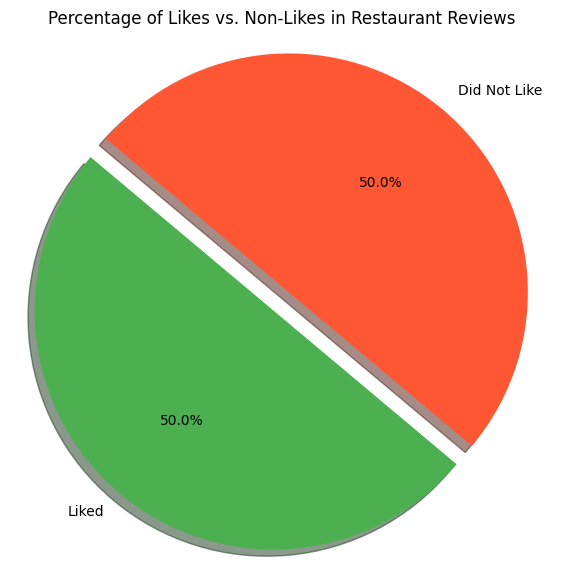

In [2]:
import matplotlib.pyplot as plt

# Calculate the overall percentage of reviews that "Liked" the restaurant
like_counts = df['Liked'].value_counts()
total_reviews = len(df)
percentage_liked = (like_counts[1] / total_reviews) * 100 if 1 in like_counts else 0
percentage_not_liked = (like_counts[0] / total_reviews) * 100 if 0 in like_counts else 0

print(f"Overall percentage of reviews that 'Liked' the restaurant: {percentage_liked:.2f}%")
print(f"Overall percentage of reviews that 'Did Not Like' the restaurant: {percentage_not_liked:.2f}%")

# Create a visualization to show the percentage of likes versus non-likes
labels = ['Liked', 'Did Not Like']
sizes = [percentage_liked, percentage_not_liked]
colors = ['#4CAF50', '#FF5733'] # Green for liked, Red for not liked
explode = (0.1, 0) # explode 1st slice (Liked)

plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of Likes vs. Non-Likes in Restaurant Reviews')
plt.show()

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [3]:
import re

# Convert to lowercase
df['Review'] = df['Review'].str.lower()

# Function to remove URLs (https, http, www) and non-alphanumeric characters
def clean_text(text):
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove punctuation and non-alphanumeric characters, keeping spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

df['Review'] = df['Review'].apply(clean_text)

# Display the first few rows with cleaned reviews
df.head()

,Review,Liked
0,wow loved this place,1
1,crust is not good,0
2,not tasty and the texture was just nasty,0
3,stopped by during the late may bank holiday of...,1
4,the selection on the menu was great and so wer...,1


### ✍️ Your Response: 🔧
1. some risks that might ocur if the review junk was kept would be a noisy model which can reduce the accuracy as these inputs would be irrelevant.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


In [6]:
!pip install vaderSentiment --quiet

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment(text):
    vs = analyzer.polarity_scores(text)
    return vs['compound']

# Apply sentiment analysis
df['sentiment_score'] = df['Review'].apply(get_sentiment)

# Categorize sentiment
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(categorize_sentiment)

# Calculate percentages
sentiment_counts = df['sentiment'].value_counts()
total_reviews = len(df)

percentage_positive = (sentiment_counts.get('Positive', 0) / total_reviews) * 100
percentage_negative = (sentiment_counts.get('Negative', 0) / total_reviews) * 100
percentage_neutral = (sentiment_counts.get('Neutral', 0) / total_reviews) * 100

print(f"Percentage of Positive reviews: {percentage_positive:.2f}%")
print(f"Percentage of Negative reviews: {percentage_negative:.2f}%")
print(f"Percentage of Neutral reviews: {percentage_neutral:.2f}%")
print(f"Total percentage: {percentage_positive + percentage_negative + percentage_neutral:.2f}%")

df.head()

Percentage of Positive reviews: 50.60%
Percentage of Negative reviews: 25.50%
Percentage of Neutral reviews: 23.90%
Total percentage: 100.00%


,Review,Liked,sentiment_score,sentiment
0,wow loved this place,1,0.8271,Positive
1,crust is not good,0,-0.3412,Negative
2,not tasty and the texture was just nasty,0,-0.5574,Negative
3,stopped by during the late may bank holiday of...,1,0.6908,Positive
4,the selection on the menu was great and so wer...,1,0.6249,Positive


### ✍️ Your Response: 🔧
1. the percentage of liked reviews was 50.6% while unliked was 25.50% and neutral was 23.98%

2. from a restuarant owners perspective i would focus on the negative reviews to know what the issue is. negative reviews can be the most impactful to someones opinion of the restaurant

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [9]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data (if not already downloaded)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True) # Open Multilingual WordNet, often needed for WordNetLemmatizer
nltk.download('punkt_tab', quiet=True) # Added to specifically download the missing resource

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function to preprocess text: tokenize, remove stopwords, lemmatize
def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    processed_tokens = [
        lemmatizer.lemmatize(word) for word in tokens if word not in stop_words
    ]
    return " ".join(processed_tokens)

# Apply preprocessing to the 'Review' column
df['processed_review'] = df['Review'].apply(preprocess_text)

# Display the first 10 processed reviews
print(df['processed_review'].head(10).to_string())

0                                      wow loved place
1                                           crust good
2                                  tasty texture nasty
3    stopped late may bank holiday rick steve recom...
4                           selection menu great price
5                          getting angry want damn pho
6                           honeslty didnt taste fresh
7    potato like rubber could tell made ahead time ...
8                                            fry great
9                                          great touch


### ✍️ Your Response: 🔧
1. corpora is a collection of text data that is used for text analysis to find patterns, frequency and sentiment.

2. the token would be wow, loved, place

3. lemmatization simplifies words into their standard form. This helps the dataset stay consistent when it comes to a variation of a single word by reducing it to its standard form and aggreagating that count

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [12]:
!pip install gensim --quiet

from gensim.corpora.dictionary import Dictionary
from gensim.models.tfidfmodel import TfidfModel

# Create a dictionary
dictionary = Dictionary([doc.split() for doc in df['processed_review']])

# Create a corpus (bag-of-words representation)
corpus = [dictionary.doc2bow(doc.split()) for doc in df['processed_review']]

# Display a summary of the dictionary
print("Dictionary Summary:")
print(f"Number of unique tokens: {len(dictionary)}")
print(f"First 10 dictionary items: {list(dictionary.items())[:10]}")

# Display a summary of the corpus
print("\nCorpus Summary (first 5 documents):")
for i, doc_bow in enumerate(corpus[:5]):
    print(f"Document {i+1}: {doc_bow}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.7 MB/s eta 0:00:00
Dictionary Summary:
Number of unique tokens: 1839
First 10 dictionary items: [(0, 'loved'), (1, 'place'), (2, 'wow'), (3, 'crust'), (4, 'good'), (5, 'nasty'), (6, 'tasty'), (7, 'texture'), (8, 'bank'), (9, 'holiday')]

Corpus Summary (first 5 documents):
Document 1: [(0, 1), (1, 1), (2, 1)]
Document 2: [(3, 1), (4, 1)]
Document 3: [(5, 1), (6, 1), (7, 1)]
Document 4: [(0, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1)]
Document 5: [(16, 1), (17, 1), (18, 1), (19, 1)]


### ✍️ Your Response: 🔧
1. corpus is when a collection of words is formated into a sort of standard format where the frequencies are then considered. It can then e used to find patterns

2. a dictionary is what gives each token its unique id.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [13]:
from gensim.models import LdaModel

# Number of topics
num_topics = 5

# Build LDA model
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=15, random_state=100)

print("LDA Model created successfully!")

LDA Model created successfully!


### ✍️ Your Response: 🔧
1. if there is a large number of potential themes that can be looked into then more than 5 topics could be useful. This could happen if the business provides a large variety of services.

2. if the topics are overlapping or repetitive then that might mean that theres too many topics.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"



--- Topics and Top 10 Words ---
Topic #0: service, place, food, star, slow, dont, waited, quality, would, disappointed
Topic #1: food, amazing, good, restaurant, also, ever, experience, like, best, place
Topic #2: great, good, food, place, service, friendly, nice, staff, eat, way
Topic #3: back, go, time, place, wont, vega, first, food, one, really
Topic #4: good, food, steak, like, really, place, probably, one, fry, minute

--- Topic Frequencies (Number of reviews per topic) ---
Dominant_Topic
0    168
1    137
2    282
3    243
4    170
Name: count, dtype: int64

--- Word Clouds for Each Topic ---


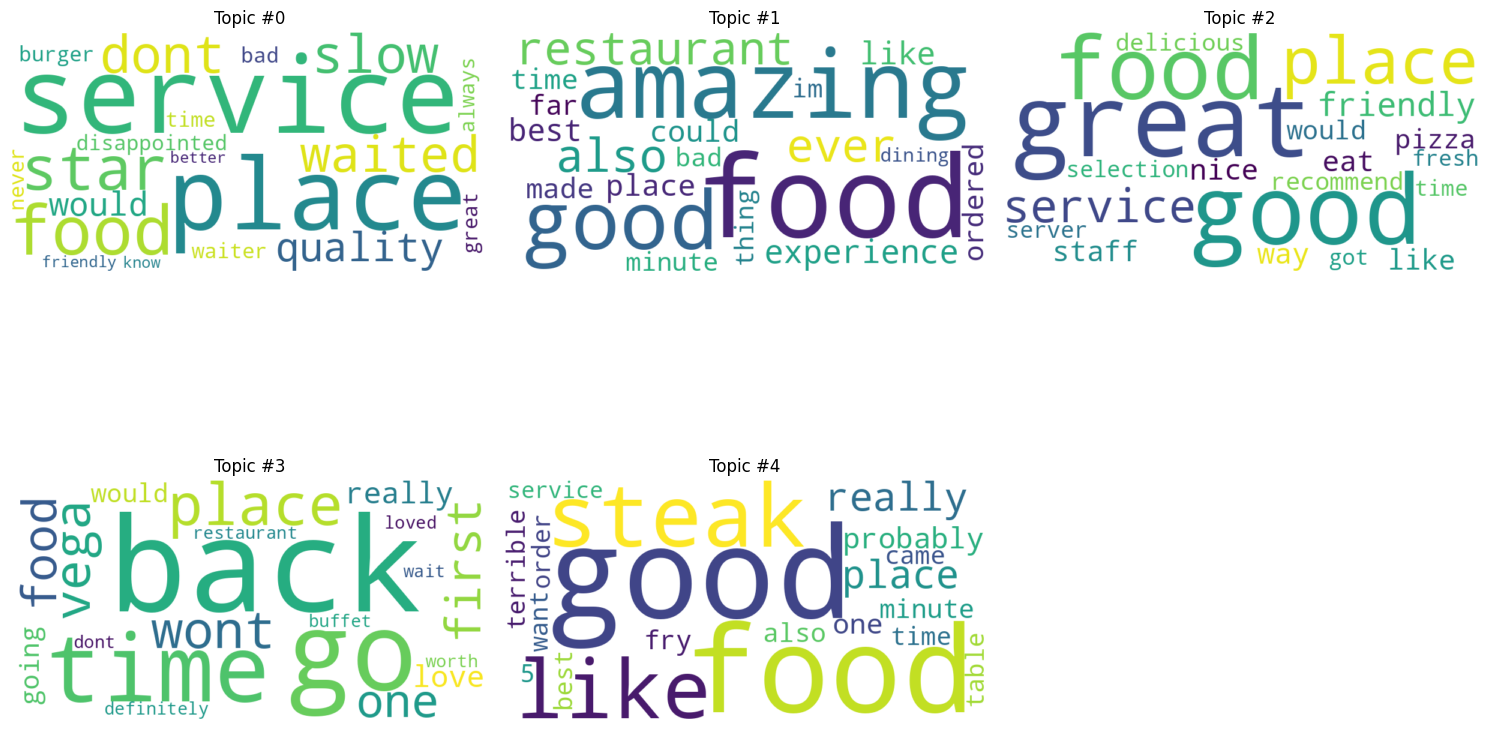


--- Sentiment Summary by Topic ---
sentiment       Positive  Neutral  Negative
Dominant_Topic                             
0                  35.12    32.14     32.74
1                  51.09    24.82     24.09
2                  64.18    13.83     21.99
3                  49.79    30.86     19.34
4                  44.12    21.76     34.12


In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import defaultdict
import re # Import regex module

# 1. Print topics and top 10 words
print("\n--- Topics and Top 10 Words ---")
topics_words = []
for idx, topic in lda_model.print_topics(num_words=10):
    # Extract words from the topic string for better readability
    words = re.findall(r'"(.*?)"', topic)
    print(f"Topic #{idx}: {', '.join(words)}")
    topics_words.append(topic)

# 2. Calculate topic frequency and assign dominant topic to each review
def get_dominant_topic(ldamodel, corpus, texts):
    topic_percent = []
    for i, row_list in enumerate(ldamodel[corpus]):
        row = row_list[0] if ldamodel.per_word_topics else row_list # Handle different gensim versions
        row = sorted(row, key=lambda x: (x[1]), reverse=True)
        if row: # Check if row is not empty
            # Get the dominant topic, percentage contribution, and text
            topic_num = row[0][0]
            perc_contribution = row[0][1]
            topic_percent.append((topic_num, perc_contribution))
        else:
            topic_percent.append((-1, 0.0)) # Assign a placeholder for empty topics

    # Add to DataFrame
    sent_topics_df = pd.DataFrame(topic_percent, columns=['Dominant_Topic', 'Perc_Contribution'])
    return sent_topics_df

sent_topics_df = get_dominant_topic(lda_model, corpus, df['processed_review'])

# Join with original DataFrame to get sentiments
df_topic_sentiment = pd.concat([df, sent_topics_df], axis=1)

# Calculate frequency of each topic
topic_counts = df_topic_sentiment['Dominant_Topic'].value_counts().sort_index()
print("\n--- Topic Frequencies (Number of reviews per topic) ---")
print(topic_counts)

# 3. Visual display of topics (Word Clouds)
print("\n--- Word Clouds for Each Topic ---")
plt.figure(figsize=(15, 10))
for i, topic_info in enumerate(lda_model.show_topics(num_topics=num_topics, num_words=20, formatted=False)):
    topic_words = dict(topic_info[1])
    wc = WordCloud(background_color="white",
                   width=800,
                   height=400,
                   collocations=False # To avoid showing duplicates like 'good good'
                  ).generate_from_frequencies(topic_words)
    plt.subplot(2, (num_topics + 1) // 2, i + 1) # Adjust subplot grid dynamically
    plt.imshow(wc, interpolation="bilinear")
    plt.title(f'Topic #{i}')
    plt.axis("off")
plt.tight_layout()
plt.show()

# 4. Summarize sentiment by topic
print("\n--- Sentiment Summary by Topic ---")
sentiment_by_topic = df_topic_sentiment.groupby('Dominant_Topic')['sentiment'].value_counts(normalize=True).unstack(fill_value=0)
sentiment_by_topic = sentiment_by_topic * 100 # Convert to percentage

# Reorder columns to have Positive, Neutral, Negative consistently
ordered_cols = ['Positive', 'Neutral', 'Negative']
sentiment_by_topic = sentiment_by_topic[[col for col in ordered_cols if col in sentiment_by_topic.columns]]

print(sentiment_by_topic.round(2).to_string())

### ✍️ Your Response: 🔧
List your topics and names here: 0. service problems 1. good restaurant 2. good food 3. time experience 4. food review


## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


### ✍️ Your Response: 🔧
1. which aspects of the business were the most prevelentaly mentioned in reviews and what were the strongest sentiments.

2. the sentiments were a variety across their different topics which makes me suggest for the restuarant to focus on consistency. There were more positive than negative reviews but those negative reviews stand out. Focus on maintaining positive customer satisfaction.

3. Some pros are that it is quicker and easier to create. On the other a con is that its less scalable than what can be created with python. Theres less insight that one could say is reliable.

4. Analyze the dataset attached. Clean the data of punctuations and stopwords. Group the entries into clear main topics of reviews. Analyze the sentiment of each of these groupings and provide a wordcloud. Additionally provide a percantage key for positive, neutral and negative sentiments for each of the topics.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [16]:
!jupyter nbconvert --to html "assignment_13_VegaSamantha.ipynb"

[NbConvertApp] Converting notebook assignment_13_VegaSamantha.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 918870 bytes to assignment_13_VegaSamantha.html
